In [1]:
BASELINES = ["critic", "ema"]   # train both
STEPS = 20000                   # lower to 10000 if Cell 4 says it will take too long

In [2]:
!nvidia-smi --query-gpu=name,memory.total --format=csv
import torch
print("torch", torch.__version__, "| GPU ready:", torch.cuda.is_available())

name, memory.total [MiB]
NVIDIA A100-SXM4-80GB, 81920 MiB
torch 2.11.0+cu128 | GPU ready: True


In [3]:
import os, sys
from google.colab import drive
drive.mount("/content/drive")
!pip -q install elkai
os.chdir("/content")
OUT = "/content/drive/MyDrive/ncorl-runs"      # trained models are saved here (safe if Colab disconnects)
os.makedirs(OUT, exist_ok=True)
os.makedirs("results", exist_ok=True)
sys.path.insert(0, "/content")
print("ready")

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.1/218.1 kB 18.8 MB/s eta 0:00:00
ready


In [4]:
%%writefile /content/ncorl.py
# Neural Combinatorial Optimization with RL (Bello et al., 2017) - TSP, PyTorch 2.x
# Reference: github.com/pemami4911/neural-combinatorial-rl-pytorch (MIT)
import math, time
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F

def tour_length(coords, tour):
    p = coords.gather(1, tour.unsqueeze(-1).expand(-1, -1, 2))
    return (p - p.roll(-1, dims=1)).norm(dim=-1).sum(1)

def make_dataset(size, n, seed, device="cuda"):
    g = torch.Generator().manual_seed(seed)
    return torch.rand(size, n, 2, generator=g).to(device)

def _vec(d):
    return nn.Parameter(torch.empty(d).uniform_(-1 / math.sqrt(d), 1 / math.sqrt(d)))

def init_uniform(m):
    for p in m.parameters():
        nn.init.uniform_(p, -0.08, 0.08)

class PointerNet(nn.Module):
    def __init__(self, d=128, n_glimpses=1, clip_C=10.0):
        super().__init__()
        self.embed = nn.Linear(2, d)
        self.encoder = nn.LSTM(d, d, batch_first=True)
        self.decoder = nn.LSTMCell(d, d)
        self.g0 = nn.Parameter(torch.empty(d).uniform_(-0.08, 0.08))                  # <g> start token
        self.Wg_ref, self.Wg_q, self.vg = nn.Linear(d, d), nn.Linear(d, d), _vec(d)   # glimpse
        self.Wp_ref, self.Wp_q, self.vp = nn.Linear(d, d), nn.Linear(d, d), _vec(d)   # pointer
        self.n_glimpses, self.C = n_glimpses, clip_C

    def forward(self, coords, greedy=False, T=1.0, keep_probs=False):
        B, n, _ = coords.shape
        ar = torch.arange(B, device=coords.device)
        emb = self.embed(coords)
        enc, (h, c) = self.encoder(emb)
        h, c = h[0], c[0]
        g_ref, p_ref = self.Wg_ref(enc), self.Wp_ref(enc)
        mask = torch.zeros(B, n, dtype=torch.bool, device=coords.device)
        x = self.g0.unsqueeze(0).expand(B, -1)
        tour, logp_sum, probs = [], 0.0, []
        for _ in range(n):
            h, c = self.decoder(x, (h, c))
            q = h
            for _ in range(self.n_glimpses):
                u = (torch.tanh(g_ref + self.Wg_q(q).unsqueeze(1)) @ self.vg).masked_fill(mask, float("-inf"))
                q = torch.einsum("bn,bnd->bd", F.softmax(u, -1), enc)
            u = torch.tanh(p_ref + self.Wp_q(q).unsqueeze(1)) @ self.vp
            if self.C:
                u = self.C * torch.tanh(u)                                   # logit clipping (A.2)
            logp = F.log_softmax(u.masked_fill(mask, float("-inf")) / T, dim=-1)
            idx = logp.argmax(-1) if greedy else torch.multinomial(logp.exp(), 1).squeeze(1)
            tour.append(idx)
            logp_sum = logp_sum + logp[ar, idx]
            if keep_probs:
                probs.append(logp.exp().detach())
            mask = mask | F.one_hot(idx, n).bool()
            x = emb[ar, idx]
        return torch.stack(tour, 1), logp_sum, (torch.stack(probs, 1) if keep_probs else None)

class Critic(nn.Module):
    def __init__(self, d=128, n_process=3):
        super().__init__()
        self.embed = nn.Linear(2, d)
        self.encoder = nn.LSTM(d, d, batch_first=True)
        self.W_ref, self.W_q, self.v = nn.Linear(d, d), nn.Linear(d, d), _vec(d)
        self.head = nn.Sequential(nn.Linear(d, d), nn.ReLU(), nn.Linear(d, 1))
        self.n_process = n_process

    def forward(self, coords):
        enc, (h, _) = self.encoder(self.embed(coords))
        q, ref = h[0], self.W_ref(enc)
        for _ in range(self.n_process):
            a = F.softmax(torch.tanh(ref + self.W_q(q).unsqueeze(1)) @ self.v, -1)
            q = torch.einsum("bn,bnd->bd", a, enc)
        return self.head(q).squeeze(-1)

@torch.no_grad()
def evaluate(actor, data):
    actor.eval()
    tour, _, _ = actor(data, greedy=True)
    return tour_length(data, tour).mean().item()

@torch.no_grad()
def sample_best(actor, data, K=1280, T=1.0, chunk=131072):
    actor.eval()
    G, best = max(1, chunk // K), []
    for i in range(0, data.shape[0], G):
        x = data[i:i + G].repeat_interleave(K, 0)
        tour, _, _ = actor(x, T=T)
        best.append(tour_length(x, tour).view(-1, K).min(1).values)
    return torch.cat(best).mean().item()

def train(n=20, steps=20000, batch=512, lr=1e-3, baseline="critic", beta=0.8,
          seed=0, device="cuda", eval_every=500, ckpt=None):
    torch.manual_seed(seed); np.random.seed(seed)
    torch.backends.cuda.matmul.allow_tf32 = True; torch.backends.cudnn.allow_tf32 = True
    val = make_dataset(1000, n, seed=1234, device=device)
    actor = PointerNet().to(device); init_uniform(actor)
    opt = torch.optim.Adam(actor.parameters(), lr=lr)
    sch = torch.optim.lr_scheduler.StepLR(opt, 5000, 0.96)
    if baseline == "critic":
        critic = Critic().to(device); init_uniform(critic)
        opt_c = torch.optim.Adam(critic.parameters(), lr=lr)
        sch_c = torch.optim.lr_scheduler.StepLR(opt_c, 5000, 0.96)
    ema, hist, t0 = None, [], time.time()
    for step in range(1, steps + 1):
        actor.train()
        coords = torch.rand(batch, n, 2, device=device)
        tour, logp, _ = actor(coords)
        L = tour_length(coords, tour)
        if baseline == "critic":
            b = critic(coords)
            loss_c = F.mse_loss(b, L)
            opt_c.zero_grad(); loss_c.backward()
            nn.utils.clip_grad_norm_(critic.parameters(), 1.0); opt_c.step(); sch_c.step()
            b = b.detach()
        else:
            ema = L.mean() if ema is None else beta * ema + (1 - beta) * L.mean()
            b = ema
        loss = ((L - b) * logp).mean()                                       # REINFORCE, eq. (5)
        opt.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(actor.parameters(), 1.0); opt.step(); sch.step()
        if step == 1 or step % eval_every == 0:
            v = evaluate(actor, val)
            hist.append(dict(step=step, train_len=L.mean().item(), val_greedy=v,
                             minutes=(time.time() - t0) / 60))
            print(f"[{baseline}] step {step:6d} | train {L.mean().item():.3f} | val greedy {v:.3f} | {hist[-1]['minutes']:.1f} min")
    if ckpt:
        torch.save({"actor": actor.state_dict(), "hist": hist, "n": n, "baseline": baseline}, ckpt)
    return actor, hist

def load_actor(path, device="cuda"):
    ck = torch.load(path, map_location=device)
    actor = PointerNet().to(device); actor.load_state_dict(ck["actor"]); actor.eval()
    return actor, ck["hist"]

# ---------- classic baselines (numpy) ----------
def dist_matrix(p):
    return np.linalg.norm(p[:, None] - p[None], axis=-1)

def length_np(p, t):
    c = p[np.append(t, t[0])]
    return np.linalg.norm(np.diff(c, axis=0), axis=1).sum()

def nearest_neighbor(p):
    D, n = dist_matrix(p), len(p)
    tour, seen = [0], np.zeros(n, bool); seen[0] = True
    for _ in range(n - 1):
        j = int(np.where(seen, np.inf, D[tour[-1]]).argmin()); tour.append(j); seen[j] = True
    return np.array(tour)

def two_opt(p, tour):
    D, t, n = dist_matrix(p), tour.copy(), len(tour)
    improved = True
    while improved:
        improved = False
        for i in range(1, n - 1):
            for j in range(i + 1, n):
                a, b, c, d = t[i - 1], t[i], t[j], t[(j + 1) % n]
                if D[a, c] + D[b, d] < D[a, b] + D[c, d] - 1e-9:
                    t[i:j + 1] = t[i:j + 1][::-1].copy(); improved = True
    return t

def lkh(p):
    import elkai
    M = np.rint(dist_matrix(p) * 1e6).astype(int).tolist()
    t = elkai.DistanceMatrix(M).solve_tsp()
    return np.array(t[:-1] if len(t) == len(p) + 1 else t)

def run_baselines(data):
    methods = {"Random tour": lambda p: np.random.permutation(len(p)),
               "Nearest neighbour": nearest_neighbor,
               "NN + 2-opt": lambda p: two_opt(p, nearest_neighbor(p)),
               "LKH (near-optimal)": lkh}
    out = {}
    for name, f in methods.items():
        try:
            t0 = time.time()
            out[name] = (float(np.mean([length_np(p, f(p)) for p in data])), time.time() - t0)
            print(f"{name:20s} {out[name][0]:.4f}  ({out[name][1]:.1f}s)")
        except Exception as e:
            print(f"Skipped {name}: {e}")
    return out

Writing /content/ncorl.py


In [5]:
import time, json, glob
import numpy as np, pandas as pd, torch
from ncorl import *
t0 = time.time()
_ = train(n=20, steps=200, batch=512, baseline="critic", eval_every=100)
per_step = (time.time() - t0) / 200
print(f"\n≈ {per_step * STEPS * len(BASELINES) / 60:.0f} minutes total for both training runs")

[critic] step      1 | train 10.485 | val greedy 8.951 | 0.0 min
[critic] step    100 | train 7.448 | val greedy 7.431 | 0.1 min
[critic] step    200 | train 7.447 | val greedy 7.410 | 0.2 min

≈ 62 minutes total for both training runs


In [6]:
for bl in BASELINES:
    ckpt = f"{OUT}/tsp20_{bl}.pt"
    if os.path.exists(ckpt):                       # already trained earlier? skip it
        print(f"{bl}: found saved model, skipping training")
        _, hist = load_actor(ckpt)
    else:
        _, hist = train(n=20, steps=STEPS, batch=512, baseline=bl, ckpt=ckpt)
    json.dump(hist, open(f"results/tsp20_hist_{bl}.json", "w"))
print("training done ✅")

critic: found saved model, skipping training
ema: found saved model, skipping training
training done ✅


In [7]:
test = make_dataset(1000, 20, seed=2026)
rows = []
for bl in BASELINES:
    actor, _ = load_actor(f"{OUT}/tsp20_{bl}.pt")
    t = time.time(); rows.append((f"RL greedy ({bl})", evaluate(actor, test), time.time() - t))
    for T in [1.0, 2.0]:
        t = time.time()
        rows.append((f"RL sampling x1280, T={T} ({bl})", sample_best(actor, test, K=1280, T=T), time.time() - t))
print("\nClassic baselines:")
base = run_baselines(test.cpu().numpy())
rows += [(k, m, s) for k, (m, s) in base.items()]

df = pd.DataFrame(rows, columns=["method", "avg_len", "seconds"])
lk = df.loc[df.method.str.startswith("LKH"), "avg_len"]
ref = float(lk.iloc[0]) if len(lk) else 3.82       # fallback: paper's TSP20 optimum
df["gap_%"] = 100 * (df.avg_len / ref - 1)
df = df.sort_values("avg_len").reset_index(drop=True)
df.to_csv("results/tsp20_table.csv", index=False)
df.round(3)



Classic baselines:
Random tour          10.3775  (0.0s)
Nearest neighbour    4.4965  (0.1s)
NN + 2-opt           3.9458  (0.9s)
LKH (near-optimal)   3.8453  (5.0s)


,method,avg_len,seconds,gap_%
0,LKH (near-optimal),3.845,5.026,0.000
1,"RL sampling x1280, T=2.0 (critic)",3.908,3.467,1.628
2,NN + 2-opt,3.946,0.929,2.614
3,"RL sampling x1280, T=2.0 (ema)",3.957,3.470,2.907
4,"RL sampling x1280, T=1.0 (critic)",3.963,3.495,3.060
5,"RL sampling x1280, T=1.0 (ema)",4.005,3.470,4.164
6,RL greedy (critic),4.020,0.018,4.556
7,RL greedy (ema),4.191,0.017,8.982
8,Nearest neighbour,4.496,0.116,16.935
9,Random tour,10.377,0.027,169.877


better baseline: critic


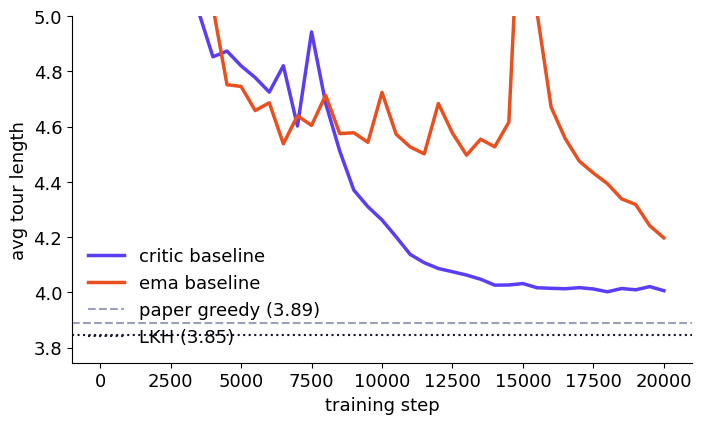

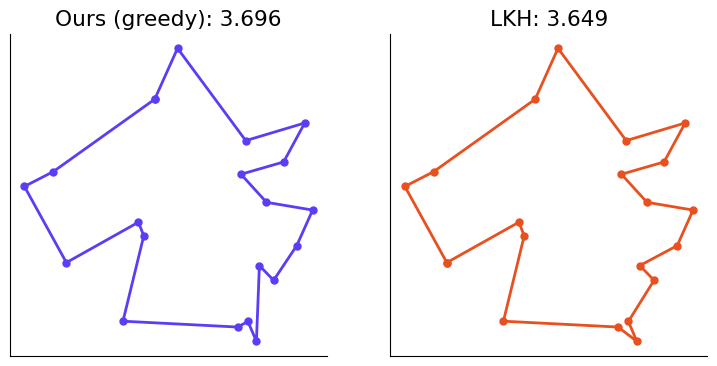

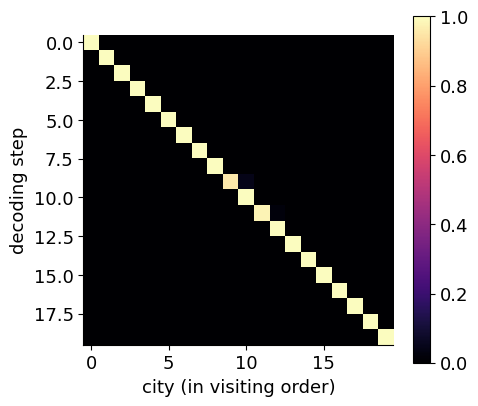

In [8]:
import matplotlib.pyplot as plt
plt.rcParams.update({"font.size": 13, "axes.spines.top": False, "axes.spines.right": False})
COL = {"critic": "#5B3DF5", "ema": "#E8501F"}

# 1) training curves
fig, ax = plt.subplots(figsize=(8, 4.5))
for bl in BASELINES:
    h = json.load(open(f"results/tsp20_hist_{bl}.json"))
    ax.plot([r["step"] for r in h], [r["val_greedy"] for r in h], lw=2.5, color=COL[bl], label=f"{bl} baseline")
ax.axhline(3.89, ls="--", c="#9AA0B8", label="paper greedy (3.89)")
ax.axhline(ref, ls=":", c="#14172E", label=f"LKH ({ref:.2f})")
ax.set_ylim(ref - 0.1, 5.0)
ax.set(xlabel="training step", ylabel="avg tour length"); ax.legend(frameon=False)
fig.savefig("results/fig_training_curve.png", dpi=200, bbox_inches="tight")

# 2) our tour vs LKH (using the better model)
best_bl = min(BASELINES, key=lambda b: df.loc[df.method == f"RL greedy ({b})", "avg_len"].item())
print("better baseline:", best_bl)
actor, _ = load_actor(f"{OUT}/tsp20_{best_bl}.pt")
with torch.no_grad():
    tour, _, probs = actor(test[:1], greedy=True, keep_probs=True)
pts, t_rl = test[0].cpu().numpy(), tour[0].cpu().numpy()
fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
for ax, t, name, col in zip(axes, [t_rl, lkh(pts)], ["Ours (greedy)", "LKH"], ["#5B3DF5", "#E8501F"]):
    c = np.append(t, t[0]); ax.plot(pts[c, 0], pts[c, 1], "-o", c=col, lw=2, ms=5)
    ax.set_title(f"{name}: {length_np(pts, t):.3f}"); ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
fig.savefig("results/fig_tours.png", dpi=200, bbox_inches="tight")

# 3) attention heatmap
fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(probs[0].cpu().numpy()[:, t_rl], cmap="magma"); fig.colorbar(im)
ax.set(xlabel="city (in visiting order)", ylabel="decoding step")
fig.savefig("results/fig_attention.png", dpi=200, bbox_inches="tight")
plt.show()

In [9]:
!cp /content/ncorl.py results/
!zip -qr results.zip results
from google.colab import files
files.download("results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

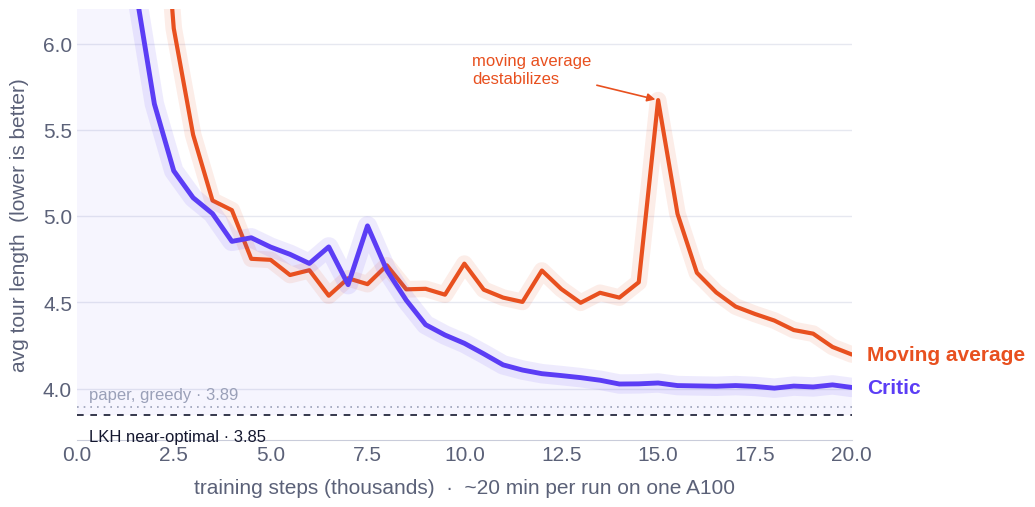

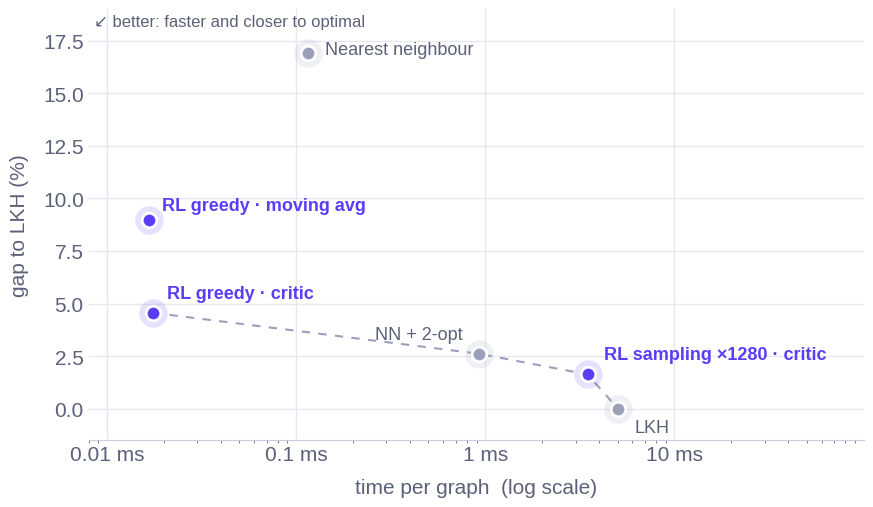

In [10]:
import logging, numpy as np, matplotlib.pyplot as plt
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
plt.rcParams.update({"font.family": ["Helvetica Neue", "Helvetica", "Arial", "Liberation Sans", "DejaVu Sans"],
    "font.size": 15, "axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False,
    "axes.edgecolor": "#C9CCDA", "xtick.color": "#5B6178", "ytick.color": "#5B6178", "axes.labelcolor": "#5B6178",
    "xtick.major.size": 0, "ytick.major.size": 0, "savefig.transparent": True})
VIO, COR, INK, MU, GRID = "#5B3DF5", "#E8501F", "#14172E", "#5B6178", "#E6E8F0"
os.makedirs("figs", exist_ok=True) if "os" in dir() else __import__("os").makedirs("figs", exist_ok=True)

steps = np.array([1] + list(range(500, 20001, 500))) / 1000
critic = [8.951,7.52,7.132,6.338,5.65,5.262,5.106,5.014,4.853,4.874,4.82,4.778,4.725,4.821,4.602,4.943,4.685,4.512,4.37,4.31,4.262,4.201,4.137,4.107,4.086,4.075,4.063,4.048,4.026,4.027,4.032,4.017,4.015,4.013,4.017,4.012,4.002,4.014,4.009,4.021,4.006]
ema    = [9.672,7.499,7.453,7.503,7.53,6.088,5.471,5.09,5.034,4.752,4.746,4.658,4.686,4.538,4.639,4.605,4.714,4.575,4.578,4.544,4.724,4.573,4.527,4.502,4.684,4.577,4.497,4.555,4.527,4.616,5.672,5.013,4.671,4.557,4.475,4.432,4.394,4.339,4.318,4.241,4.197]
LKH, PAPER = 3.845, 3.89

# --- training curves ---
fig, ax = plt.subplots(figsize=(10, 5.6))
ax.yaxis.grid(True, color=GRID, lw=1); ax.set_axisbelow(True)
ax.fill_between(steps, critic, LKH, color=VIO, alpha=0.05, lw=0)
for y, c, lw in [(ema, COR, 3), (critic, VIO, 3.5)]:
    ax.plot(steps, y, color=c, lw=lw * 4, alpha=0.10, solid_capstyle="round")
    ax.plot(steps, y, color=c, lw=lw, solid_capstyle="round")
ax.axhline(LKH, color=INK, lw=1.2, ls=(0, (4, 4)))
ax.axhline(PAPER, color="#9AA0B8", lw=1.2, ls=(0, (1, 3)))
ax.text(0.3, LKH - 0.08, "LKH near-optimal · 3.85", color=INK, fontsize=12, va="top")
ax.text(0.3, PAPER + 0.03, "paper, greedy · 3.89", color="#9AA0B8", fontsize=12, va="bottom")
ax.text(20.4, critic[-1], "Critic", color=VIO, fontsize=15, fontweight="bold", va="center")
ax.text(20.4, ema[-1], "Moving average", color=COR, fontsize=15, fontweight="bold", va="center")
ax.annotate("moving average\ndestabilizes", xy=(15, 5.672), xytext=(10.2, 5.85), color=COR, fontsize=12,
            arrowprops=dict(arrowstyle="-|>", color=COR, lw=1.2), va="center")
ax.set_ylim(3.7, 6.2); ax.set_xlim(0, 20)
ax.set_xlabel("training steps (thousands)  ·  ~20 min per run on one A100", labelpad=10)
ax.set_ylabel("avg tour length  (lower is better)", labelpad=10)
fig.savefig("figs/fig_curve_modern.png", dpi=250, bbox_inches="tight")

# --- quality vs speed ---
pts = [("RL greedy · critic", 0.0175, 4.56, True), ("RL greedy · moving avg", 0.0166, 8.98, True),
       ("RL sampling ×1280 · critic", 3.47, 1.63, True), ("Nearest neighbour", 0.116, 16.93, False),
       ("NN + 2-opt", 0.93, 2.61, False), ("LKH", 5.03, 0.0, False)]
offs = {"RL greedy · critic": (10, 8), "RL greedy · moving avg": (10, 4), "RL sampling ×1280 · critic": (12, 8),
        "Nearest neighbour": (12, -4), "NN + 2-opt": (-12, 8), "LKH": (12, -20)}
fig, ax = plt.subplots(figsize=(10, 5.6))
ax.yaxis.grid(True, color=GRID, lw=1); ax.xaxis.grid(True, color=GRID, lw=1); ax.set_axisbelow(True)
ax.plot(*zip(*[(0.0175, 4.56), (0.93, 2.61), (3.47, 1.63), (5.03, 0.0)]), color="#9AA0B8", lw=1.5, ls=(0, (4, 4)), zorder=1)
for name, x, y, ours in pts:
    c = VIO if ours else "#9AA0B8"
    ax.scatter(x, y, s=420, color=c, alpha=0.15, lw=0, zorder=2)
    ax.scatter(x, y, s=110, color=c, edgecolor="white", lw=2, zorder=3)
    dx, dy = offs[name]
    ax.annotate(name, (x, y), xytext=(dx, dy), textcoords="offset points", fontsize=13, color=VIO if ours else MU,
                fontweight="bold" if ours else "normal", ha="right" if dx < 0 else "left", va="bottom")
ax.set_xscale("log"); ax.set_xlim(0.008, 100); ax.set_ylim(-1.5, 19)
ax.set_xticks([0.01, 0.1, 1, 10]); ax.set_xticklabels(["0.01 ms", "0.1 ms", "1 ms", "10 ms"])
ax.set_xlabel("time per graph  (log scale)", labelpad=10); ax.set_ylabel("gap to LKH (%)", labelpad=10)
ax.text(0.0085, 18.2, "↙ better: faster and closer to optimal", color=MU, fontsize=12)
fig.savefig("figs/fig_frontier.png", dpi=250, bbox_inches="tight")
plt.show()

RL greedy · moving avg       mean gap  9.01% | median  7.69% | matches LKH on   1.7% of graphs
RL greedy · critic           mean gap  4.58% | median  3.86% | matches LKH on   6.9% of graphs
RL sampling ×1280 · critic   mean gap  1.64% | median  0.93% | matches LKH on  29.2% of graphs


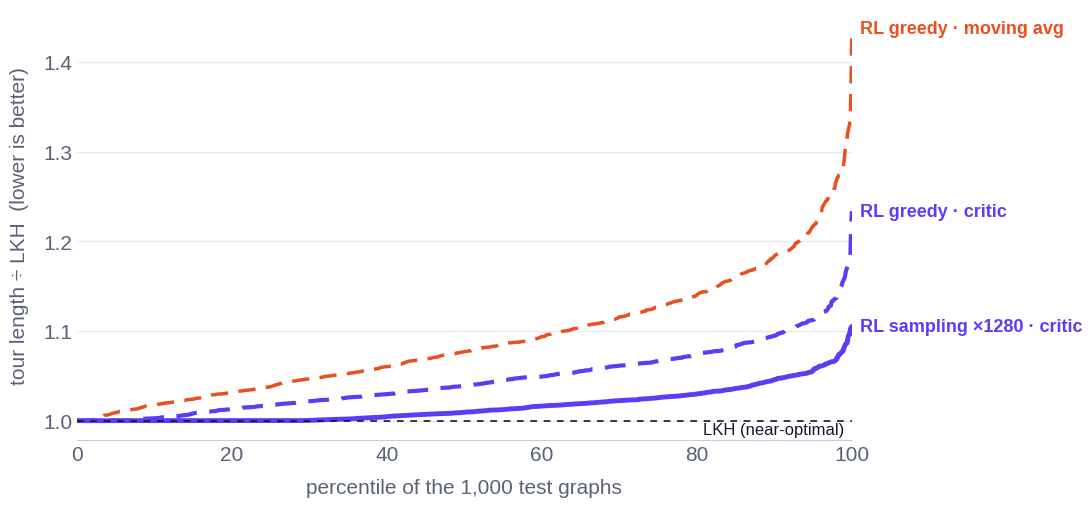

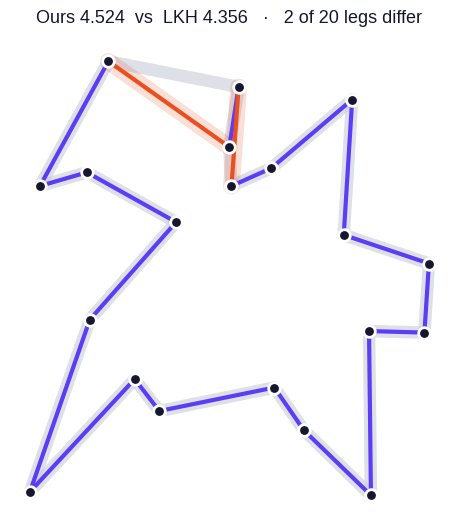

In [11]:
import torch
from ncorl import *
test = make_dataset(1000, 20, seed=2026)
P = test.cpu().numpy()
t_lkh = [lkh(p) for p in P]
L_lkh = np.array([length_np(p, t) for p, t in zip(P, t_lkh)])

@torch.no_grad()
def per_graph(actor, greedy=True, K=1280, T=2.0):
    if greedy:
        tour, _, _ = actor(test, greedy=True)
        return tour_length(test, tour).cpu().numpy(), tour.cpu().numpy()
    best = []
    for i in range(0, len(test), 100):
        x = test[i:i + 100].repeat_interleave(K, 0)
        tour, _, _ = actor(x, T=T)
        best.append(tour_length(x, tour).view(-1, K).min(1).values)
    return torch.cat(best).cpu().numpy(), None

critic_m, _ = load_actor(f"{OUT}/tsp20_critic.pt"); ema_m, _ = load_actor(f"{OUT}/tsp20_ema.pt")
L_c, T_c = per_graph(critic_m); L_e, _ = per_graph(ema_m); L_s, _ = per_graph(critic_m, greedy=False)
ratios = {"RL greedy · moving avg": L_e / L_lkh, "RL greedy · critic": L_c / L_lkh, "RL sampling ×1280 · critic": L_s / L_lkh}
for k, r in ratios.items():
    print(f"{k:28s} mean gap {100*(r.mean()-1):5.2f}% | median {100*(np.median(r)-1):5.2f}% | matches LKH on {100*np.mean(r < 1 + 1e-4):5.1f}% of graphs")

# --- our Figure 2: sorted ratio to LKH ---
fig, ax = plt.subplots(figsize=(10, 5.6))
ax.yaxis.grid(True, color=GRID, lw=1); ax.set_axisbelow(True)
style = {"RL greedy · moving avg": (COR, (0, (5, 3)), 2.5), "RL greedy · critic": (VIO, (0, (5, 3)), 3), "RL sampling ×1280 · critic": (VIO, "-", 3.5)}
for name, r in ratios.items():
    c, ls, lw = style[name]; y = np.sort(r)
    ax.plot(np.linspace(0, 100, len(y)), y, color=c, ls=ls, lw=lw, solid_capstyle="round")
    ax.text(101, y[-1], name, color=c, fontsize=13, fontweight="bold", va="center")
ax.axhline(1.0, color=INK, lw=1.2, ls=(0, (4, 4)))
ax.text(99, 0.998, "LKH (near-optimal)", color=INK, fontsize=12, va="top", ha="right")
ax.set_xlim(0, 100); ax.set_xlabel("percentile of the 1,000 test graphs", labelpad=10)
ax.set_ylabel("tour length ÷ LKH  (lower is better)", labelpad=10)
fig.savefig("figs/fig_sorted_ratio.png", dpi=250, bbox_inches="tight")

# --- a typical graph: which legs differ from LKH ---
def edges(t): return {frozenset((int(t[k]), int(t[(k + 1) % len(t)]))) for k in range(len(t))}
i = int(np.argmin(np.abs(ratios["RL greedy · critic"] - np.median(ratios["RL greedy · critic"]))))
pts, e_rl, e_lkh = P[i], edges(T_c[i]), edges(t_lkh[i])
fig, ax = plt.subplots(figsize=(6.2, 6.2)); ax.set_aspect("equal"); ax.axis("off")
for e in e_lkh:
    a, b = pts[list(e)]; ax.plot([a[0], b[0]], [a[1], b[1]], color="#C9CCDA", lw=9, alpha=0.6, solid_capstyle="round", zorder=1)
for e in e_rl:
    a, b = pts[list(e)]; bad = e not in e_lkh; c = COR if bad else VIO
    if bad: ax.plot([a[0], b[0]], [a[1], b[1]], color=c, lw=12, alpha=0.18, solid_capstyle="round", zorder=2)
    ax.plot([a[0], b[0]], [a[1], b[1]], color=c, lw=3, solid_capstyle="round", zorder=3)
ax.scatter(pts[:, 0], pts[:, 1], s=70, color=INK, edgecolor="white", lw=2, zorder=4)
ax.set_title(f"Ours {L_c[i]:.3f}  vs  LKH {L_lkh[i]:.3f}   ·   {len(e_rl - e_lkh)} of 20 legs differ", color=INK, fontsize=13, pad=12)
fig.savefig("figs/fig_tour_diff.png", dpi=250, bbox_inches="tight")
plt.show()

In [12]:
!zip -qr figs.zip figs
from google.colab import files; files.download("figs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>